In [1]:
!pip install -q transformers torch torchvision scikit-learn pillow matplotlib

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

100%|██████████| 792M/792M [01:10<00:00, 11.3MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 7.86MB/s]


Cluster Assignments: [0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0]
Ground Truth Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


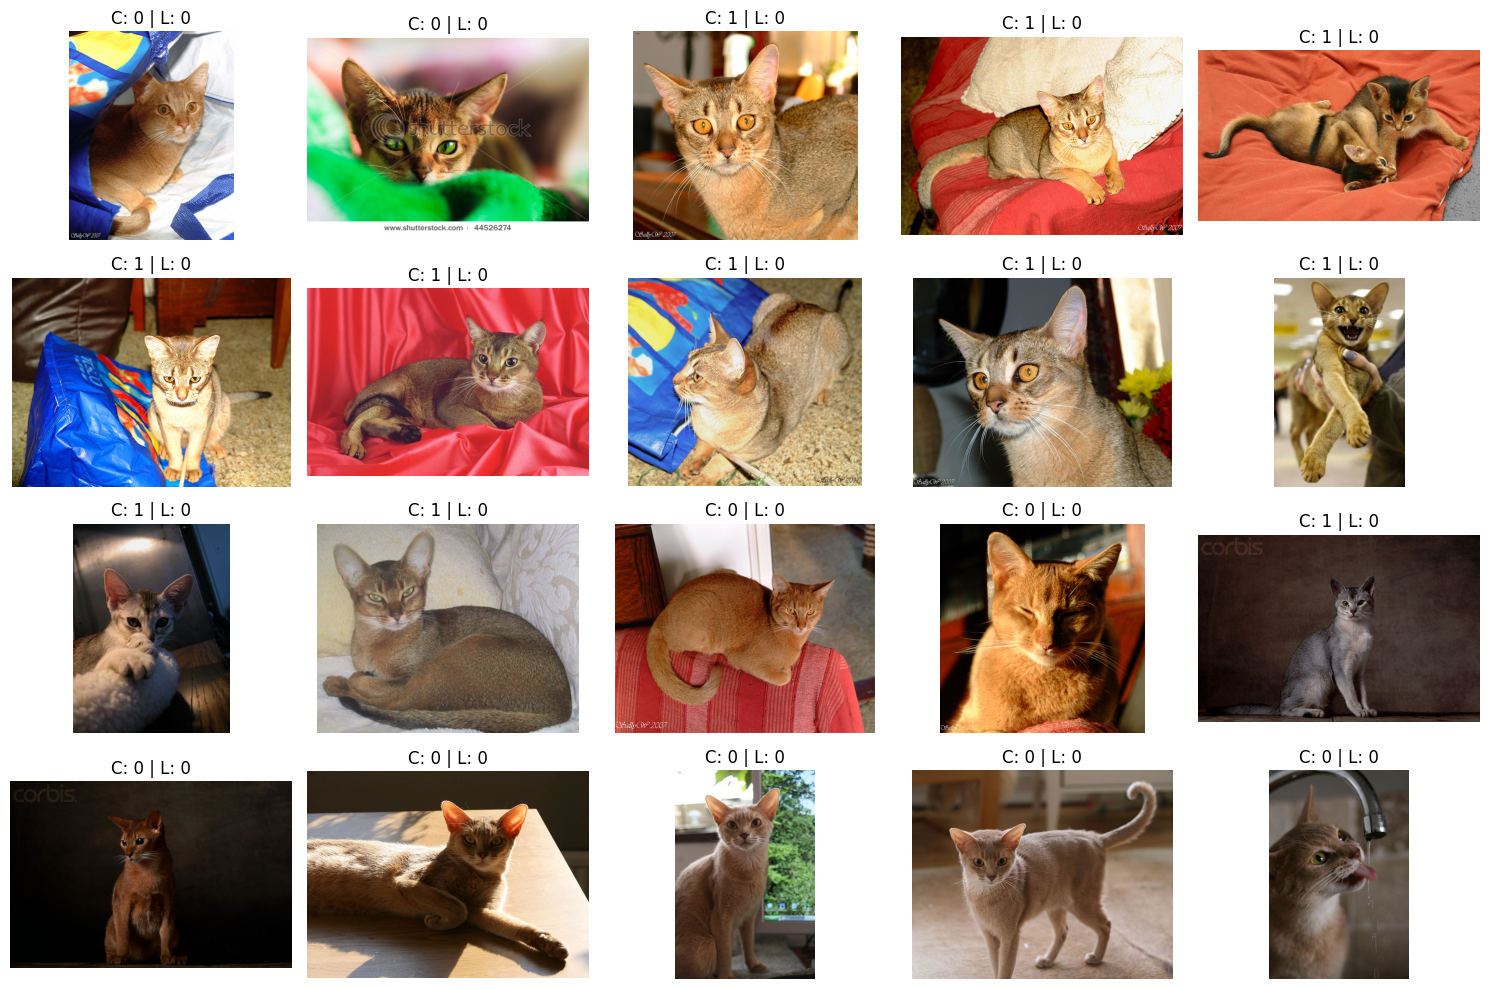

In [2]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt

# 1. Load DINOv2 model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/dinov2-small"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# 2. Load the Dataset
dataset = OxfordIIITPet(root='./data', download=True)

# 3. Extract CLS tokens for 20 images
features = []
labels = [] # Ground truth (0 for Cat, 1 for Dog usually)
images_to_show = []

for i in range(20):
    img, label = dataset[i]
    images_to_show.append(img)
    labels.append(label)

    # Process image and get CLS token
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        # The CLS token is the first token of the last_hidden_state
        cls_token = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        features.append(cls_token.flatten())

features = np.array(features)

# 4. Apply K-Means (n=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features)

# 5. Compare and Print Results
print("Cluster Assignments:", clusters)
print("Ground Truth Labels:", labels)

# Visualization of results
fig, axes = plt.subplots(4, 5, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_to_show[i])
    ax.set_title(f"C: {clusters[i]} | L: {labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
!pip install -q transformers torch torchvision pillow requests matplotlib

import torch
import requests
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import matplotlib.pyplot as plt

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(DEVICE)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

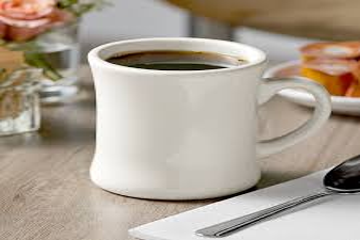

Model ID  : facebook/dinov2-small-imagenet1k-1-layer
Local Image: /content/coffee_mug.jpeg
Rank  ImageNet Label                     Confidence
1     cup                                23.17%
2     coffee mug                         21.88%
3     espresso                           16.18%
4     consomme                           13.93%
5     eggnog                             11.55%


In [9]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

image_processor = AutoImageProcessor.from_pretrained(MODEL_ID)
classifier = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(DEVICE)
classifier.eval()

image_path = r"/content/coffee_mug.jpeg"
image = Image.open(image_path).convert("RGB")

display(image.resize((360, 240)))

inputs = image_processor(images=image, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    logits = classifier(**inputs).logits[0]
    probs = torch.softmax(logits, dim=0)
    top_probs, top_ids = torch.topk(probs, 5)

print("=" * 55)
print(f"Model ID  : {MODEL_ID}")
print(f"Local Image: {image_path}")
print("=" * 55)
print(f"{'Rank':<6}{'ImageNet Label':<35}{'Confidence':<10}")
print("=" * 55)

for rank, (idx, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
    label = classifier.config.id2label[idx]
    clean_label = label.split(",")[0] if "," in label else label
    print(f"{rank:<6}{clean_label:<35}{prob:.2%}")
print("=" * 55)